In [1]:
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import gc
from opacus import PrivacyEngine
from torch.utils.data import random_split


transform = transforms.Compose([
    transforms.ToTensor(),  
])

train_dataset = datasets.MNIST(root='./data', train=True, transform=transform, download=True)
test_dataset  = datasets.MNIST(root='./data', train=False, transform=transform, download=True)
train_size_private = int(0.96 * len(train_dataset))
train_size_public = len(train_dataset) - train_size_private
train_dataset_public, train_dataset_private = random_split(train_dataset, [train_size_public, train_size_private])
train_loader_public = DataLoader(dataset=train_dataset_public, batch_size=64, shuffle=True)
train_loader_private = DataLoader(dataset=train_dataset_private, batch_size=64, shuffle=True)
test_loader  = DataLoader(dataset=test_dataset, batch_size=1000, shuffle=False)


In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

class mnist(nn.Module):
    def __init__(self):
        super(mnist, self).__init__()
        self.conv1 = nn.Conv2d(1,6, kernel_size=5, stride=1, padding=2)
        self.tanh1 = nn.Tanh()
        self.pool1 = nn.AvgPool2d(kernel_size=2,  stride=2)
        self.conv2 = nn.Conv2d(6, 16, kernel_size=5, stride=1)
        self.tanh2 = nn.Tanh()
        self.pool2 = nn.AvgPool2d(kernel_size=2, stride=2)
        self.conv3 = nn.Conv2d(16, 120, kernel_size=5, stride=1)
        self.tanh3 = nn.Tanh()
        self.fc1 = nn.Linear(120, 84)
        self.tanh4 = nn.Tanh()
        self.fc2 = nn.Linear(84, 10)

    def forward(self, x):
        x = self.pool1(self.tanh1(self.conv1(x)))
        x = self.pool2(self.tanh2(self.conv2(x)))
        x = self.tanh3(self.conv3(x))
        x = x.view(-1, 120)  # Flatten the tensor
        x = self.tanh4(self.fc1(x))
        x = self.fc2(x)
        return x

model = mnist()
criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(model.parameters(), lr=0.01, momentum=0.9)

privacy_engine = PrivacyEngine()


gc.collect()

/Users/rubenhayrapetyan/Library/Python/3.9/lib/python/site-packages/opacus/privacy_engine.py:96: UserWarning: Secure RNG turned off. This is perfectly fine for experimentation as it allows for much faster training performance, but remember to turn it on and retrain one last time before production with ``secure_mode`` turned on.
  warnings.warn(


0

In [3]:
epochs_1 = 5
train_losses = []
train_accuracies = []
test_losses = []
test_accuracies = []
for epoch in range(epochs_1):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for inputs, labels in train_loader_public:
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * inputs.size(0)
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()
    print(f'Epoch [{epoch + 1}/10]')
    print("Training loss", (running_loss / total))  
    train_losses.append(running_loss / total)
    print("Training accuracy", (correct *100/ total),'%')
    train_accuracies.append(correct * 100 / total)
    gc.collect()


    model.eval()
    running_loss_eval = 0.0
    correct = 0
    total = 0

    with torch.no_grad():
        for inputs, labels in test_loader:
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            running_loss_eval += loss.item() * inputs.size(0)
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    print("Testing loss", (running_loss / total))
    test_losses.append(running_loss_eval / total)
    print("Testing accuracy", (correct*100 / total),'%')
    test_accuracies.append(correct * 100 / total)
    gc.collect()

Epoch [1/10]
Training loss 2.2868677520751954
Training accuracy 15.666666666666666 %
Testing loss 0.5488482604980469
Testing accuracy 25.41 %
Epoch [2/10]
Training loss 2.1441935539245605
Training accuracy 43.166666666666664 %
Testing loss 0.5146064529418946
Testing accuracy 53.28 %
Epoch [3/10]
Training loss 1.431574411392212
Training accuracy 61.416666666666664 %
Testing loss 0.3435778587341309
Testing accuracy 73.03 %
Epoch [4/10]
Training loss 0.7814964095751444
Training accuracy 77.125 %
Testing loss 0.18755913829803467
Testing accuracy 83.28 %
Epoch [5/10]
Training loss 0.5563210372130076
Training accuracy 84.25 %
Testing loss 0.13351704893112182
Testing accuracy 85.44 %


In [ ]:
epochs_1 = 5
train_losses_2 = []
train_accuracies_2 = []
test_losses_2 = []
test_accuracies_2 = []
model.train()
model, optimizer, train_loader_private = privacy_engine.make_private_with_epsilon(
    module=model,
    optimizer=optimizer,
    data_loader=train_loader_private,
    epochs=10,
    target_epsilon=3,
    target_delta=1e-5,
    max_grad_norm=0.1,
)
epochs_2 = 10
for epoch in range(epochs_2):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for inputs, labels in train_loader_private:
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * inputs.size(0)
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()
    print(f'Epoch [{epoch + 1}/10]')
    print("Training loss", (running_loss / total))
    train_losses_2.append(running_loss / total)
    print("Training accuracy", (correct *100/ total),'%')
    train_accuracies_2.append(correct * 100 / total)
    gc.collect()


    model.eval()
    running_loss_eval = 0.0
    correct = 0
    total = 0

    with torch.no_grad():
        for inputs, labels in test_loader:
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            running_loss_eval += loss.item() * inputs.size(0)
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    print("Testing loss", (running_loss / total))
    test_losses_2.append(running_loss_eval / total)
    print("Testing accuracy", (correct*100 / total),'%')
    test_accuracies_2.append(correct * 100 / total)

    gc.collect()

/Users/rubenhayrapetyan/Library/Python/3.9/lib/python/site-packages/opacus/accountants/analysis/rdp.py:332: UserWarning: Optimal order is the largest alpha. Please consider expanding the range of alphas to get a tighter privacy bound.
  warnings.warn(


Epoch [1/10]
Training loss 0.5146372968999284
Training accuracy 83.93071424844786 %
Testing loss 2.9592159209042785
Testing accuracy 84.53 %
Epoch [2/10]
Training loss 0.5123012676194634
Training accuracy 84.14634146341463 %
Testing loss 2.9490110169246795
Testing accuracy 85.49 %
Epoch [3/10]
Training loss 0.4869464330650194
Training accuracy 85.15452825932289 %
Testing loss 2.806126209823787
Testing accuracy 86.33 %
Epoch [4/10]
Training loss 0.4644391708540193
Training accuracy 86.02169167330815 %
Testing loss 2.6806500063352288
Testing accuracy 86.67 %


In [ ]:
model.eval()
correct = 0
total = 0
eval_loss = 0.0

with torch.no_grad():
    for inputs, labels in test_loader:
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        eval_loss += loss.item() * inputs.size(0)
        _, predicted = torch.max(outputs.data, 1)
        correct += (predicted == labels).sum().item()
        total += labels.size(0)

print(f"Test Loss: {eval_loss / total:.4f}, Accuracy: {100 * correct / total:.2f}%")

Test Loss: 0.4855, Accuracy: 87.99%


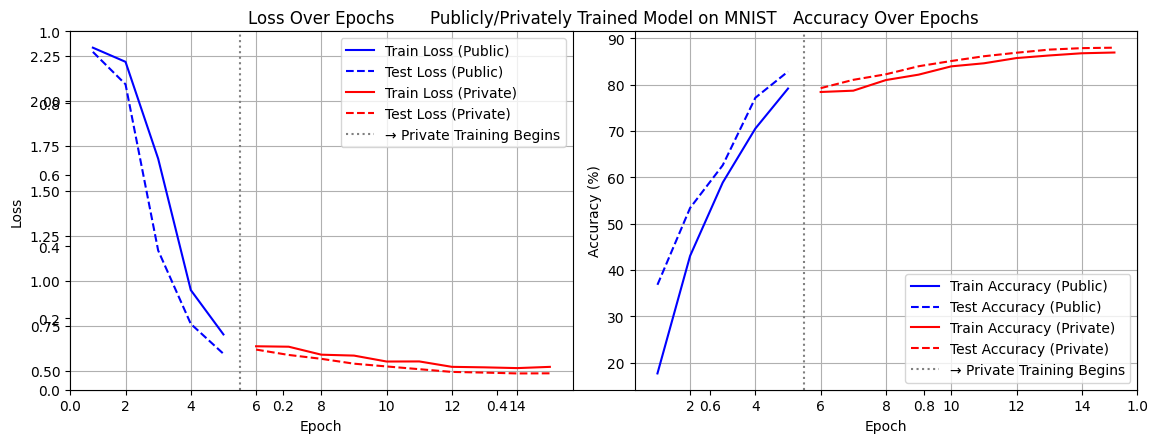

In [ ]:
import matplotlib.pyplot as plt

# Combine loss and accuracy for plotting
full_train_losses = train_losses + train_losses_2
full_test_losses = test_losses + test_losses_2
full_train_accuracies = train_accuracies + train_accuracies_2
full_test_accuracies = test_accuracies + test_accuracies_2

# Create epoch ranges
public_epochs = list(range(1, epochs_1 + 1))
private_epochs = list(range(epochs_1 + 1, epochs_1 + epochs_2 + 1))

plt.figure(figsize=(12, 5))
plt.title('Publicly/Privately Trained Model on MNIST')
# --- Loss Plot ---
plt.subplot(1, 2, 1)
# Public Phase
plt.plot(public_epochs, train_losses, 'b-', label='Train Loss (Public)')
plt.plot(public_epochs, test_losses, 'b--', label='Test Loss (Public)')

# Private Phase
plt.plot(private_epochs, train_losses_2, 'r-', label='Train Loss (Private)')
plt.plot(private_epochs, test_losses_2, 'r--', label='Test Loss (Private)')

plt.axvline(x=epochs_1 + 0.5, color='gray', linestyle=':', label='→ Private Training Begins')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Loss Over Epochs')
plt.legend()
plt.grid(True)

# --- Accuracy Plot ---
plt.subplot(1, 2, 2)
# Public Phase
plt.plot(public_epochs, train_accuracies, 'b-', label='Train Accuracy (Public)')
plt.plot(public_epochs, test_accuracies, 'b--', label='Test Accuracy (Public)')

# Private Phase
plt.plot(private_epochs, train_accuracies_2, 'r-', label='Train Accuracy (Private)')
plt.plot(private_epochs, test_accuracies_2, 'r--', label='Test Accuracy (Private)')

plt.axvline(x=epochs_1 + 0.5, color='gray', linestyle=':', label='→ Private Training Begins')
plt.xlabel('Epoch')
plt.ylabel('Accuracy (%)')
plt.title('Accuracy Over Epochs')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()
